# Esame Laboratorio di Programmazione II

Scrivete chiaramente sul notebook il vostro nome e matricola e salvate il file con il nome della vostra matricola.

Per ogni funzione o metodo che richiede un campionamento rispetto ad una distribuzione, settate il seed a 0: `np.random.seed(0)`.

Stampate il risultato delle domande e consegnate il compito eseguito: ogni cella deve avere il corrispondente output. Ad esempio, NON scrivete solo:

```python
lista = np.array([1, 2, 3])
```

ma:

```python
lista = np.array([1, 2, 3])
print('lista =', lista)
```

NB: se l'output è una matrice molto grande, non dovete stamparla integralmente.

Sarà valutata anche la presentazione: ad esempio, un plot senza titolo o senza etichette sugli assi sarà considerato incompleto.


In [63]:
# Qui potete mettere gli import delle librerie 
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy.optimize import curve_fit

In [ ]:
#NOME COGNOME E MATRICOLA
# AURORA GARDISAN SM32A00056

## Esercizio 1

Un gruppo di supereroi ha ottenuto i seguenti punteggi di energia dopo una missione:

`72, 85, 61, 90, 77, 88, 54, 69, 95, 81, 73, 66`

1. Crea un array NumPy `energia` con questi valori e calcola la **media**.
2. Tutti i valori **strettamente minori di 70** devono essere aumentati di 8 punti. Aggiorna l'array in-place e stampa il nuovo array.
3. Calcola quanti valori, dopo la correzione, sono **compresi tra 75 e 90 inclusi**.


In [11]:
#1
energia = np.array([72, 85, 61, 90, 77, 88, 54, 69, 95, 81, 73, 66])
media = np.mean(energia)
print("Media: ", media)
#2
energia[energia < 70] += 8
print("Array modificato:", energia)
#3
condizione = (energia >=75)&(energia <=90)
somma = np.sum(condizione)
print("Valori compresi tra 75 e 90 inclusi: ", somma)

Media:  75.91666666666667
Array modificato: [72 85 69 90 77 88 62 77 95 81 73 74]
Valori compresi tra 75 e 90 inclusi:  6


## Esercizio 2

Un supereroe affronta una missione. L'esito della missione può essere:

- `successo`, con probabilità 0.65;
- `successo_parziale`, con probabilità 0.25;
- `fallimento`, con probabilità 0.10.

1. Scrivi una funzione `simula_missioni(N)` che simula `N` missioni e restituisce un array NumPy con gli esiti ottenuti.
2. Per valori di `N = 50, 100, 150, ..., 500`, esegui una simulazione e calcola la frequenza relativa di `successo` e di `fallimento`.
3. Rappresenta graficamente le frequenze relative di `successo` e `fallimento` in funzione di `N` e confrontale con i valori teorici.


In [15]:
#1
def simula_missioni(N):
    esiti = ["successo", "successo_parziale", "fallimento"]
    probabilita = [0.65, 0.25, 0.1]
    simulazione = np.random.choice(esiti, size=N, p=probabilita)
    return simulazione
#2
valori_N = np.arange(50, 501, 50)
frequenza_successo = []
frequenza_fallimento = []
for N in valori_N:
    esiti_ottenuti = simula_missioni
    freq_succ= np.sum(esiti_ottenuti == "successo")/N
    freq_fall=np.sum(esiti_ottenuti=="fallimento")/N

    frequenza_successo.append(freq_succ)
    frequenza_fallimento.append(freq_fall)
#3
fig = go.Figure()
#freq. empirica successo
fig.add_trace(go.Scatter(
    x = valori_N, y=frequenza_successo,
    name="Freq. successo",
    line=dict(color="blue")
))
#valore teorico
fig.add_trace(go.Scatter(
    x=valori_N, y=[0.65]*len(valori_N),
    name="Prob. successo teorica",
    line=dict(color="darkblue")
))
#freq empirica fallimento
fig.add_trace(go.Scatter(
    x=valori_N, y=frequenza_fallimento,
    name="Prob. fallimento",
    line=dict(color="red")
))
#valore teorico fallim
fig.add_trace(go.Scatter(
    x=valori_N, y=[0.1]*len(valori_N),
    name="Prob fallimento teorica",
    line=dict(color="darkred")
))
fig.update_layout(
    title="Legge dei grandi numeri: freq relative VS prob teorica",
    xaxis_title="Numero di Missioni(N)",
    yaxis_title="frequenza/prob"
)
fig.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni 6 × 8, con valori estratti da una distribuzione normale con media = 50 e deviazione standard = 10.

2. Per ogni riga, individua il valore massimo e il valore minimo.

3. Costruisci un array contenente, per ogni riga, la differenza tra il valore massimo e il valore minimo.

4. Calcola quante righe hanno una differenza maggiore di 20.

In [ ]:
#1
matrice = np.random.normal(loc=50, scale=10, size=(6,8))
print("Matrice: ", matrice)
#2
massimi_righe = np.max(matrice, axis = 1)
minimi_righe = np.min(matrice, axis = 1)
print(f"Massimi per ogni riga : {massimi_righe}, minimi per ogni riga: {minimi_righe}")
#3
differenze = massimi_righe - minimi_righe
arr_diff = np.array(differenze)
print("Array contenente la differenza tra il valore massimo e il valore minimo: ", arr_diff)
#4
vero_falso = differenze > 20
somma = np.sum(vero_falso)
print("Numero righe che hanno differenza > 20:", somma)

Matrice:  [[36.22115323 45.33022891 37.80337362 57.39822634 60.42377077 48.90424732
  58.19382652 65.43729354]
 [43.93695722 57.11234818 59.53754206 49.07039365 52.70404106 60.68559423
  64.64644743 44.65654946]
 [49.42507253 50.04542143 63.05087823 67.09205509 40.41465289 45.05811426
  58.15365563 39.28416867]
 [62.91406462 45.22595256 45.84946505 44.70705498 62.2525386  49.27672528
  62.89803988 59.92812932]
 [41.49053049 53.25542273 44.24261361 52.09989879 46.37117279 56.0243221
  49.580841   46.69165108]
 [64.07573369 53.41764043 65.31820895 72.58180402 57.87091613 63.16346078
  40.05919658 41.01017477]]
Massimi per ogni riga : [65.43729354 64.64644743 67.09205509 62.91406462 56.0243221  72.58180402], minimi per ogni riga: [36.22115323 43.93695722 39.28416867 44.70705498 41.49053049 40.05919658]
Array contenente la differenza tra il valore massimo e il valore minimo:  [29.21614031 20.70949021 27.80788642 18.20700964 14.53379161 32.52260744]
Numero righe che hanno differenza > 20: 4

## Esercizio 4

Utilizza il dataset `heroes.csv`, che contiene le seguenti colonne:

`hero_id`, `hero`, `universe`, `strength`, `speed`, `intelligence`, `missions`, `success_rate`, `power_type`.

1. Verifica la presenza di **valori mancanti per colonna** ed elimina le righe che ne contengono.

2. Crea una nuova colonna `mission_score` definita come:

   $$
   \texttt{mission\_score}
   =
   \texttt{missions}
   \times
   \texttt{success\_rate}
   $$

3. Calcola il valore medio di `mission_score` per ciascun universo (`Marvel` e `DC`) e determina quale universo ha il valore medio più elevato.

4. Crea un **grafico a barre** che mostri il valore medio di `mission_score` per ciascun universo.

5. Crea uno **scatter plot** con:
   - asse x = `strength`
   - asse y = `success_rate`
   - colore dei punti = `mission_score`

Valori mancanti per colonna:  hero_id         0
hero            0
universe        0
strength        0
speed           5
intelligence    0
missions        5
success_rate    5
power_type      5
dtype: int64
Valori medi dei due universi:  universe
DC        18709.714000
Marvel    18127.898936
Name: mission_score, dtype: float64


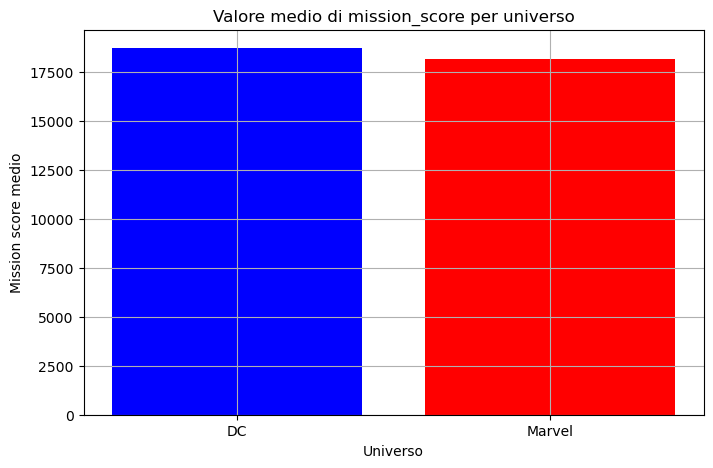

In [42]:
df = pd.read_csv("heroes.csv")
#1
val_manc = df.isnull().sum()
print("Valori mancanti per colonna: ", val_manc)
df = df.dropna()
df.head()
#2
df["mission_score"] = df["missions"]*df["success_rate"]
df.head()
#3
medie_universi = df.groupby("universe")["mission_score"].mean()
print("Valori medi dei due universi: ", medie_universi)
#4
plt.figure(figsize=(8,5))
plt.bar(medie_universi.index, medie_universi.values, color=["blue", "red"])
plt.title("Valore medio di mission_score per universo")
plt.xlabel("Universo")
plt.ylabel("Mission score medio")
plt.grid(True)
plt.show()
#oppure, più elegante:
df_medie = medie_universi.reset_index()
fig_bar = px.bar(
    df_medie,
    x="universe",
    y="mission_score",
    title="Valore medio di mission score per universo",
    color="universe"
)
fig_bar.show()
#5
fig_scat = px.scatter(
    df,
    x="strength",
    y="success_rate",
    color="mission_score",
    title="Scatterplot",
    labels={
        "strength": "Forza",
        "success_rate": "Percentuale di successo",
        "mission_score": "Mission score"
    }
)
fig_scat.show()

## Esercizio 5

**Prima di svolgere questo esercizio, ricaricare il dataset originale `heroes.csv`.**

Si utilizzi di nuovo il dataset `heroes.csv`.

Svolgere le seguenti richieste:

1. Determinare il numero di righe e di colonne del dataset ed eliminare la colonna `hero_id`.
2. Individuare il `power_type` più frequente nel dataset.
3. Calcolare la media di `success_rate` per ciascun `power_type` e ordinare i risultati dal valore medio più alto al più basso.
4. Rappresentare la distribuzione di `success_rate` per ciascun `power_type` mediante un boxplot.
5. Calcolare la percentuale di eroi con `success_rate >= 90` e con `success_rate < 90` **usando una list comprehension**, e rappresentare tali percentuali con un grafico a torta (pie chart).


Numero di righe e colonne:  (120, 9)
Il power_type più frequente è:  Mutation
Media per power_type di success_rate:  power_type
Alien         87.294737
Skill         85.125000
Speed         85.012500
Mutation      84.575000
Technology    83.983333
Magic         83.594737
Name: success_rate, dtype: float64


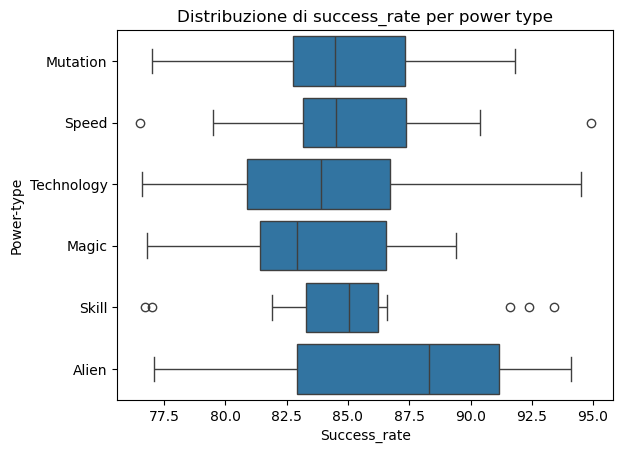

Percentuale eroi >=90 :15.0, percentuale eroi <90: 80.83333333333333


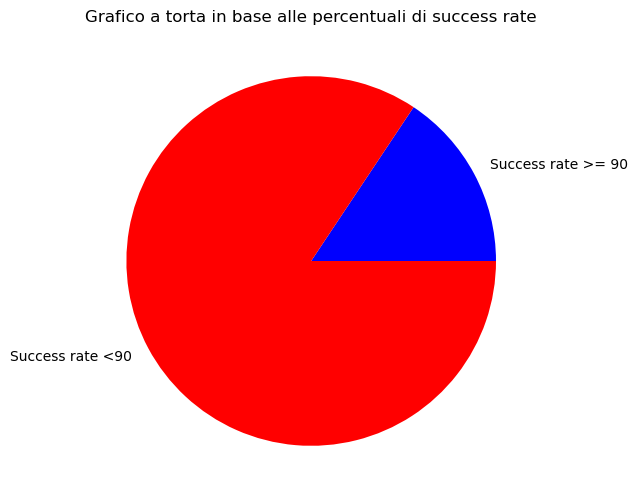

In [62]:
df = pd.read_csv("heroes.csv")
#1
num_r_c = df.shape
print("Numero di righe e colonne: ", num_r_c)
df = df.drop(columns=["hero_id"])
df.head()
#2
power_type_freq = df["power_type"].mode()[0]
print("Il power_type più frequente è: ", power_type_freq)
#3
media_group = df.groupby("power_type")["success_rate"].mean()
media_group = media_group.sort_values(ascending=False)
print("Media per power_type di success_rate: ", media_group)
#4
sns.boxplot(data = df, x="success_rate", y="power_type")
plt.title("Distribuzione di success_rate per power type")
plt.xlabel("Success_rate")
plt.ylabel("Power-type")
plt.show()
#5
lista = df["success_rate"].tolist()
num_eroi = len(lista)
eroi_alti = len([x for x in lista if x>=90])
eroi_bassi = len([x for x in lista if x<90])
perc_alti = (eroi_alti/num_eroi)*100
perc_bassi = (eroi_bassi/num_eroi)*100
print(f"Percentuale eroi >=90 :{perc_alti}, percentuale eroi <90: {perc_bassi}")

etichette = ["Success rate >= 90", "Success rate <90"]
percentuali = [perc_alti, perc_bassi]
plt.figure(figsize=(6,6))
plt.pie(
    percentuali,
    labels=etichette,
    colors=["blue", "red"]
)
plt.title("Grafico a torta in base alle percentuali di success rate")
plt.show()


## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.

1. Stima i parametri della retta del tipo

   $$
   y = a \cdot x + b
   $$

   usando `scipy.optimize.curve_fit`.
2. Plotta i punti originali e la retta ottenuta.
3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


In [64]:
x = np.array([
    0.0, 0.5, 1.0, 1.5, 2.0, 2.5,
    3.0, 3.5, 4.0, 4.5, 5.0, 5.5,
    6.0, 6.5, 7.0, 7.5, 8.0, 8.5,
    9.0, 9.5, 10.0
])

y = np.array([
    2.1, 3.2, 4.7, 6.0, 7.5, 8.8,
    10.2, 12.0, 13.1, 14.9, 16.3, 17.8,
    19.0, 20.7, 22.1, 23.6, 25.2, 26.4,
    28.0, 29.3, 31.1
])


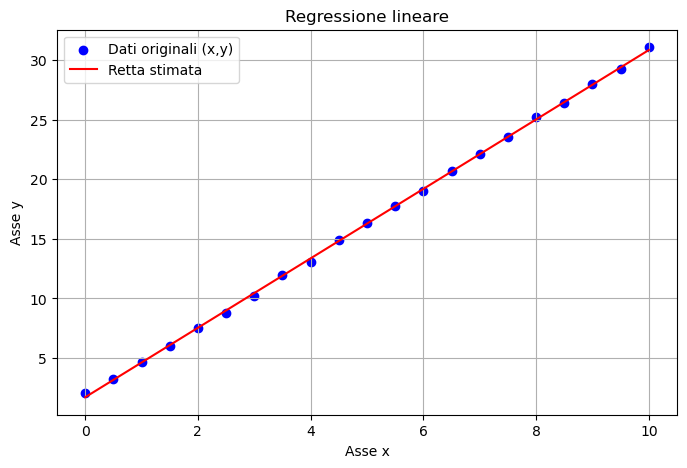

MAE: 0.11955473080574522, RMSE: 0.15595973347725214


In [66]:
#1
def modello(x,a,b):
    return a*x +b
popt, pcov = curve_fit(modello, x, y)
a_stim, b_stim = popt
#2
y_pred = modello(x, a_stim, b_stim)
plt.figure(figsize=(8,5))
plt.scatter(x, y, color="blue", label="Dati originali (x,y)")
plt.plot(x, y_pred, color="red", label="Retta stimata")
plt.title("Regressione lineare")
plt.xlabel("Asse x")
plt.ylabel("Asse y")
plt.legend()
plt.grid(True)
plt.show()
#3
n = len(y)
mae = np.mean(np.abs(y-y_pred))
rmse = np.sqrt(np.mean((y-y_pred)**2))
print(f"MAE: {mae}, RMSE: {rmse}")